# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
# read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os
import pandas as pd

# Select the folder having data files
os.chdir('/content/drive/MyDrive/upgrad/C1MA-EDA/data_NYC_Taxi/trip_records')

# Create a list of all the twelve files to read
file_list = sorted([f for f in os.listdir() if f.endswith('.parquet')])

# Initialise an empty dataframe to hold final data
df = pd.DataFrame()

# Iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        temp_df = pd.read_parquet(file_path)

        # Convert to datetime to extract date and hour
        temp_df['tpep_pickup_datetime'] = pd.to_datetime(temp_df['tpep_pickup_datetime'])
        temp_df['pickup_date'] = temp_df['tpep_pickup_datetime'].dt.date
        temp_df['pickup_hour'] = temp_df['tpep_pickup_datetime'].dt.hour

        # Sample 5% of the entries for each hour of every date
        # group_keys=False ensures we don't create a multi-index
        sampled_month = temp_df.groupby(['pickup_date', 'pickup_hour'], group_keys=False).apply(lambda x: x.sample(frac=0.05, random_state=42))

        # Concatenate the sampled data to the final dataframe
        df = pd.concat([df, sampled_month], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

print(f"Sampling complete. Total rows: {len(df)}")
display(df.head())

Sampling complete. Total rows: 1896400


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,0.5,2.00,0.0,1.0,13.50,2.5,0.00,2022-12-31,23,NaN
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the sampled df for faster access later
df.to_parquet('/content/sampled_nyc_taxi_2023.parquet')
print("Sampled data saved successfully.")

Sampled data saved successfully.


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
df = pd.read_parquet('/content/sampled_nyc_taxi_2023.parquet')
print("Data loaded from saved parquet.")

Data loaded from saved parquet.


In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,0.5,2.00,0.0,1.0,13.50,2.5,0.00,2022-12-31,23,NaN
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)

# Based on the data dictionary, we can drop store_and_fwd_flag and pickup_date as we have the full datetime
# and potentially any columns that are purely internal or redundant
if 'pickup_date' in df.columns:
    df.drop(columns=['pickup_date'], inplace=True)

print("Index reset and internal columns dropped.")
display(df.info())

Index reset and internal columns dropped.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   

None

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns
# Fill NaN values in 'airport_fee' with values from 'Airport_fee'
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])

# Drop the redundant 'Airport_fee' column
df.drop(columns=['Airport_fee'], inplace=True, errors='ignore')

print("Airport fee columns merged. Current columns:")
print(df.columns.tolist())

Airport fee columns merged. Current columns:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_hour']


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# Check where values of fare amount are negative
negative_fares = df[df['fare_amount'] < 0]
print(f"Number of rows with negative fare_amount: {len(negative_fares)}")
display(negative_fares.head())

Number of rows with negative fare_amount: 0


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
print("RatecodeID distribution for negative fares:")
print(negative_fares['RatecodeID'].value_counts())

RatecodeID distribution for negative fares:
Series([], Name: count, dtype: int64)


In [ ]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=['number']).columns
neg_counts = (df[numeric_cols] < 0).sum()
print("Negative value counts per column:")
print(neg_counts[neg_counts > 0])

Negative value counts per column:
extra                     3
mta_tax                  73
improvement_surcharge    78
total_amount             78
congestion_surcharge     56
airport_fee              15
dtype: int64


In [ ]:
# Fix these negative values by taking
# Monetary values shouldn't be negative
monetary_cols = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

for col in monetary_cols:
    if col in df.columns:
        df[col] = df[col].abs()

print("Negative monetary values converted to positive.")

Negative monetary values converted to positive.


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
missing_proportions = df.isnull().mean() * 100
print("Percentage of missing values per column:")
print(missing_proportions[missing_proportions > 0])

Percentage of missing values per column:
passenger_count         3.420903
RatecodeID              3.420903
store_and_fwd_flag      3.420903
congestion_surcharge    3.420903
airport_fee             3.420903
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
null_rows = df[df['passenger_count'].isnull()]
display(null_rows.head())

# Impute NaN values in 'passenger_count'
# mode is used for passenger count as we assume at least 1 passenger if missing
mode_passengers = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(mode_passengers)

# Also handle zeros if they exist (a trip usually implies at least 1 passenger)
df.loc[df['passenger_count'] == 0, 'passenger_count'] = mode_passengers

print(f"Passenger count missing values handled. Mode used: {mode_passengers}")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
5,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,NaN,0
16,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,NaN,0
43,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,NaN,0
44,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,NaN,0
47,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,NaN,0


Passenger count missing values handled. Mode used: 1.0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
# 1 is the standard rate and most frequent. We will use the mode.
mode_ratecode = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_ratecode)

print(f"RatecodeID missing values handled. Mode used: {mode_ratecode}")

RatecodeID missing values handled. Mode used: 1.0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge
# We can assume 0 if it was not applied/recorded
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

print("Congestion surcharge null values filled with 0.")

Congestion surcharge null values filled with 0.


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Are there missing values in other columns?
print("Missing values in other columns:")
print(df.isnull().sum())

# Did you find NaN values in some other set of columns?
print("NaN values in other columns:")
print(df.isna().sum())

# Handle any remaining missing values
df.fillna(0, inplace=True)
print("Remaining missing values filled with 0.")
print("Current missing value count:", df.isnull().sum().sum())

Missing values in other columns:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count              0
trip_distance                0
RatecodeID                   0
store_and_fwd_flag       64874
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
airport_fee              64874
pickup_hour                  0
dtype: int64
NaN values in other columns:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count              0
trip_distance                0
RatecodeID                   0
store_and_fwd_flag       64874
PULocationID                 0
DOLocationID                 0
payment_type              

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
display(df[['trip_distance', 'fare_amount', 'passenger_count', 'total_amount']].describe())

# Check for potential out of place values in various columns
print("Trips where distance > 250 miles:", len(df[df['trip_distance'] > 250]))
print("Trips where payment_type 0:", len(df[df['payment_type'] == 0]))
print("Trips where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different:", len(df[(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])]))
print("Trips where trip_distance is nearly 0 and fare_amount is more than 300:", len(df[(df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)]))

,trip_distance,fare_amount,passenger_count,total_amount
count,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
mean,3.858293e+00,1.991935e+01,1.372236e+00,2.898216e+01
std,1.294085e+02,1.055371e+02,8.644038e-01,1.064161e+02
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.050000e+00,9.300000e+00,1.000000e+00,1.596000e+01
50%,1.790000e+00,1.350000e+01,1.000000e+00,2.100000e+01
75%,3.400000e+00,2.190000e+01,1.000000e+00,3.094000e+01
max,1.263605e+05,1.431635e+05,9.000000e+00,1.431675e+05


Trips where distance > 250 miles: 46
Trips where payment_type 0: 64874
Trips where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different: 63
Trips where trip_distance is nearly 0 and fare_amount is more than 300: 35


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6 and entries with 0 passengers
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
print("Filtered passenger counts between 1 and 6.")

Filtered passenger counts between 1 and 6.


In [ ]:
# Remove entries where trip_distance is nearly 0 and fare_amount is > 300
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

# Remove entries where distance and fare are 0 but zones are different
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

# Limit trip distance to 250 miles
df = df[df['trip_distance'] <= 250]

# Remove invalid payment types (assuming 1-4 are valid per dict)
df = df[df['payment_type'].isin([1, 2, 3, 4])]

print(f"Outliers handled. Remaining rows: {len(df)}")

Outliers handled. Remaining rows: 1831391


In [ ]:
# Standardize data types
df['passenger_count'] = df['passenger_count'].astype(int)
df['RatecodeID'] = df['RatecodeID'].astype(int)

# Ensure trip duration column exists for later analysis
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Remove negative or zero durations
df = df[df['trip_duration'] > 0]

print("Data standardization complete and trip_duration (minutes) calculated.")

Data standardization complete and trip_duration (minutes) calculated.


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
print("Available columns for EDA:")
print(df.columns.tolist())

Available columns for EDA:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_hour', 'trip_duration']


#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

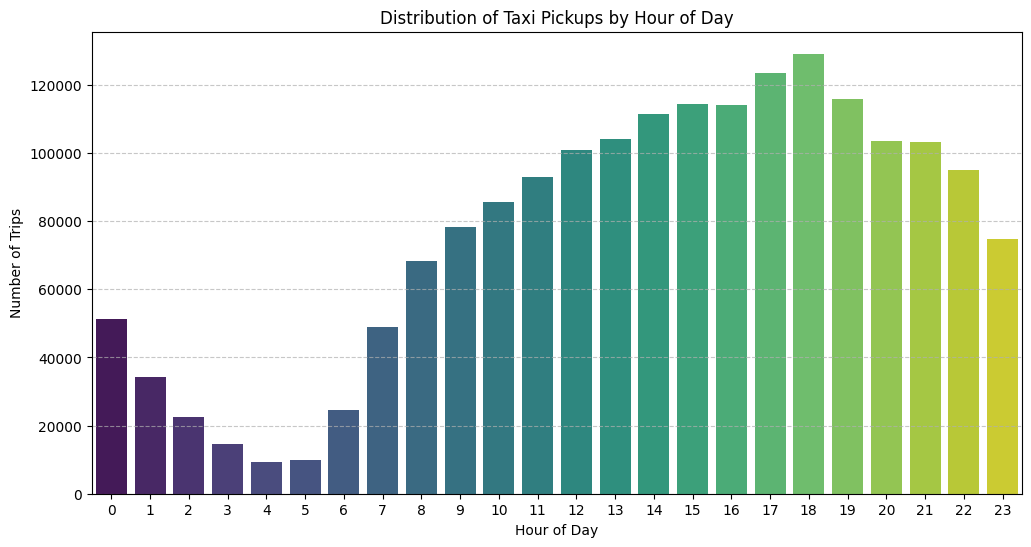

In [ ]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='pickup_hour', palette='viridis')
plt.title('Distribution of Taxi Pickups by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

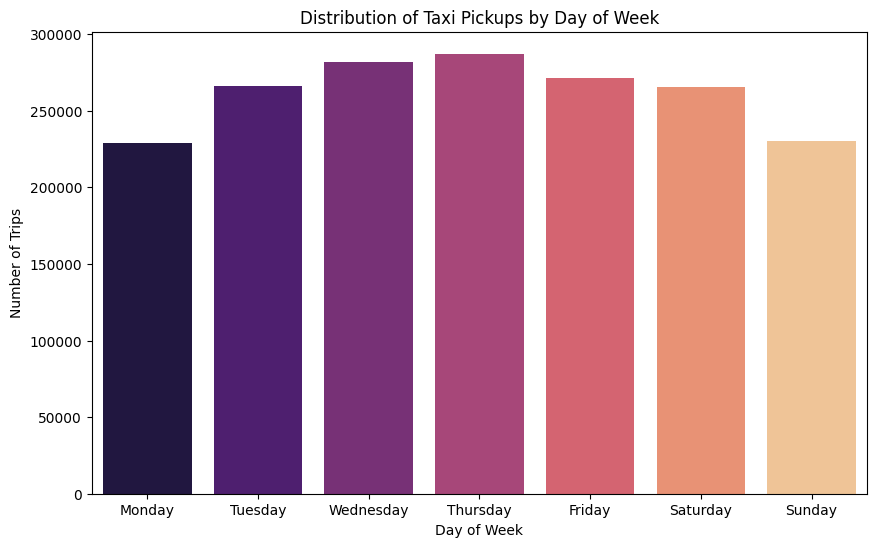

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='pickup_day', order=day_order, palette='magma')
plt.title('Distribution of Taxi Pickups by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.show()

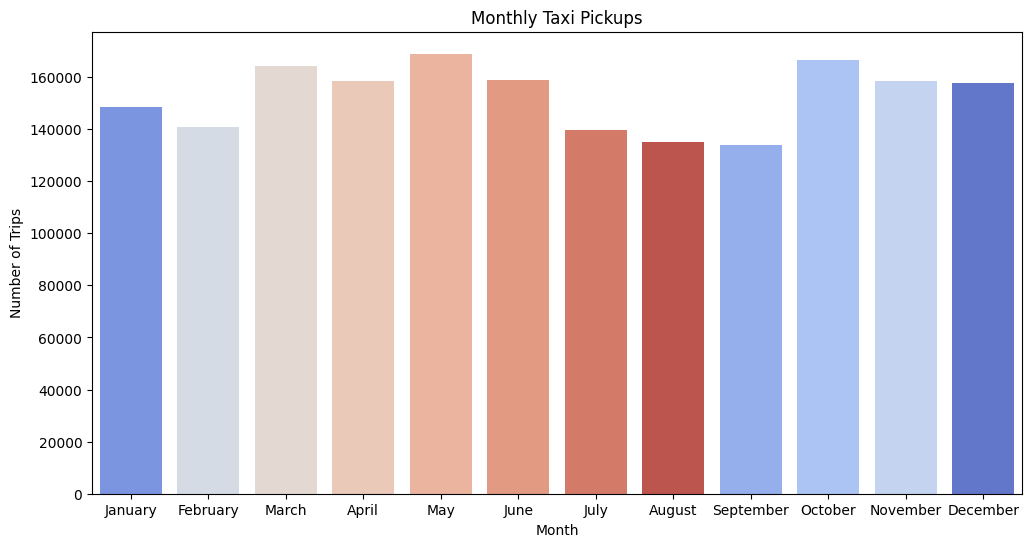

In [ ]:
# Show the monthly trends in pickups
df['month'] = df['tpep_pickup_datetime'].dt.month_name()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='month', order=months_order, hue='month', palette='coolwarm', legend=False)
plt.title('Monthly Taxi Pickups')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse financial parameters for zero/negative values
financials = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
print("Summary of financial parameters:")
display(df[financials].describe())

for col in financials:
    zeros = (df[col] == 0).sum()
    print(f"{col} has {zeros} zero values.")

Summary of financial parameters:


,fare_amount,tip_amount,total_amount,trip_distance
count,1.830707e+06,1.830707e+06,1.830707e+06,1.830707e+06
mean,1.981438e+01,3.574490e+00,2.893950e+01,3.445961e+00
std,1.073569e+02,4.069368e+00,1.082345e+02,4.546075e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.300000e+00,1.000000e+00,1.596000e+01,1.050000e+00
50%,1.350000e+01,2.860000e+00,2.100000e+01,1.790000e+00
75%,2.190000e+01,4.450000e+00,3.070000e+01,3.370000e+00
max,1.431635e+05,2.230800e+02,1.431675e+05,2.048600e+02


fare_amount has 572 zero values.
tip_amount has 409641 zero values.
total_amount has 254 zero values.
trip_distance has 22334 zero values.


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.
# We exclude rows where fare_amount or total_amount is 0.
# We keep trip_distance = 0 if PULocationID == DOLocationID as it might be a valid wait/cancellation.
df_filtered = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0)].copy()
df_filtered = df_filtered[(df_filtered['trip_distance'] > 0) | ((df_filtered['trip_distance'] == 0) & (df_filtered['PULocationID'] != df_filtered['DOLocationID']))]
print(f"Filtered zero fares. Remaining records: {len(df_filtered)}")

Filtered zero fares. Remaining records: 1815187


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

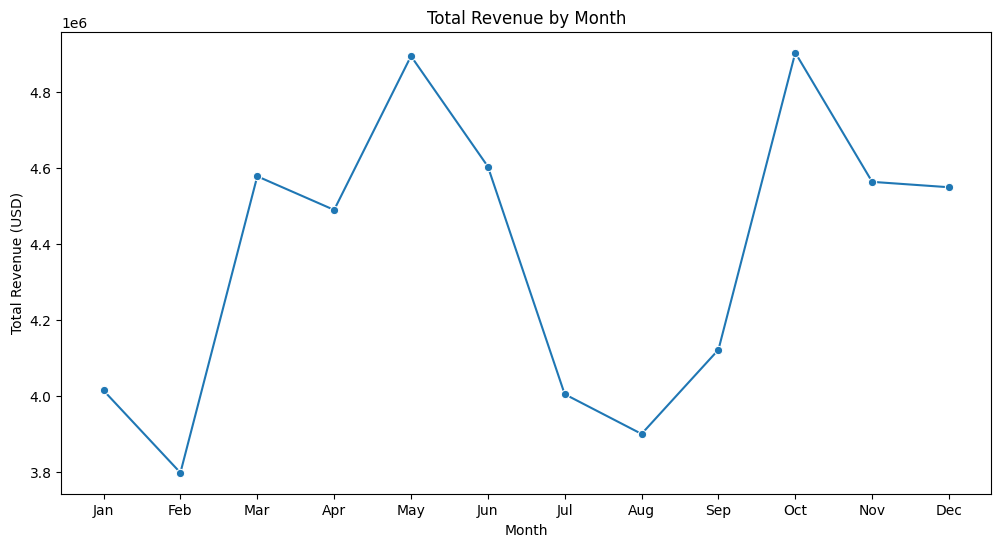

In [ ]:
# Group data by month and analyse monthly revenue
df_filtered['pickup_month'] = df_filtered['tpep_pickup_datetime'].dt.month
monthly_revenue = df_filtered.groupby('pickup_month')['total_amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='pickup_month', y='total_amount', marker='o')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

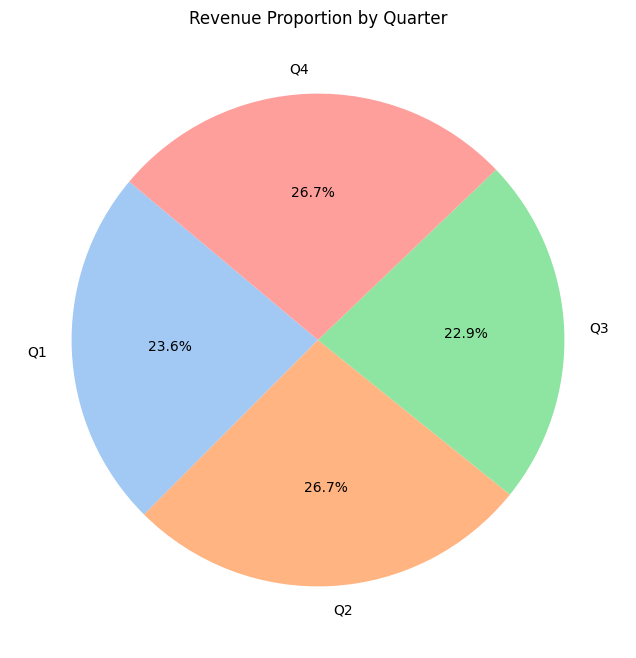

In [ ]:
# Calculate proportion of each quarter
df_filtered['quarter'] = df_filtered['tpep_pickup_datetime'].dt.quarter
quarterly_rev = df_filtered.groupby('quarter')['total_amount'].sum()

plt.figure(figsize=(8, 8))
plt.pie(quarterly_rev, labels=['Q1', 'Q2', 'Q3', 'Q4'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Revenue Proportion by Quarter')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

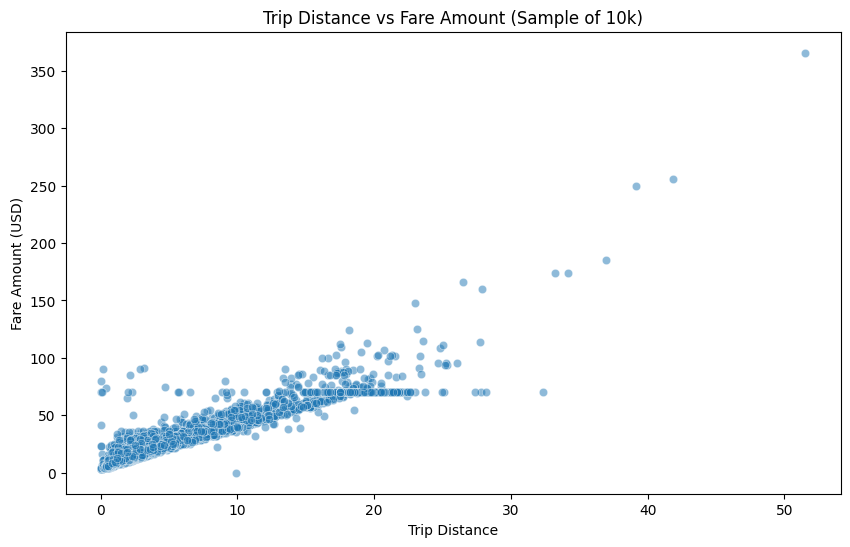

Correlation between trip distance and fare amount: 0.1560


In [ ]:
# Show how trip fare is affected by distance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered[df_filtered['trip_distance'] > 0].sample(10000), x='trip_distance', y='fare_amount', alpha=0.5)
plt.title('Trip Distance vs Fare Amount (Sample of 10k)')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount (USD)')
plt.show()

corr = df_filtered[['trip_distance', 'fare_amount']].corr().iloc[0, 1]
print(f"Correlation between trip distance and fare amount: {corr:.4f}")

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

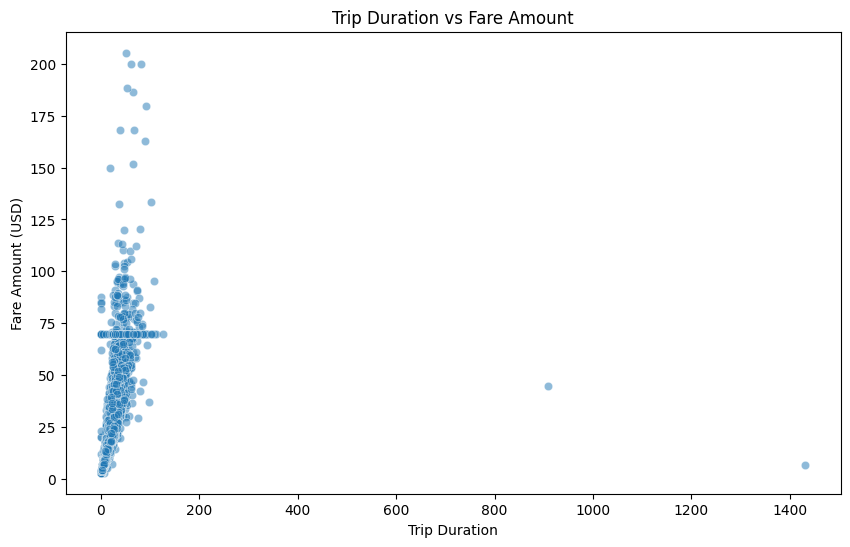

Correlation: 0.0456


In [ ]:
# Show relationship between fare and trip duration
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered.sample(10000), x='trip_duration', y='fare_amount', alpha=0.5)
plt.title('Trip Duration vs Fare Amount')
plt.xlabel('Trip Duration')
plt.ylabel('Fare Amount (USD)')
plt.show()

print(f"Correlation: {df_filtered[['trip_duration', 'fare_amount']].corr().iloc[0,1]:.4f}")

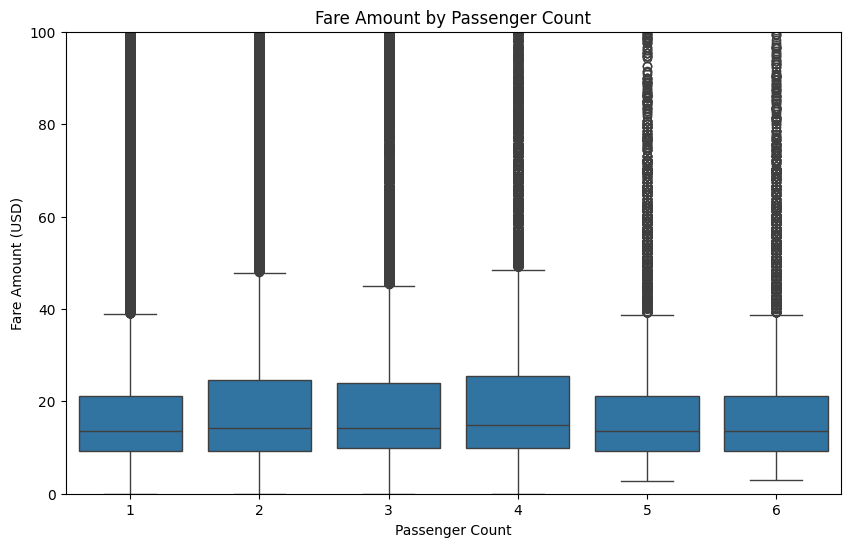

Correlation between Fare and Passenger Count: 0.01


In [ ]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered, x='passenger_count', y='fare_amount')
plt.ylim(0, 100)
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount (USD)')
plt.show()

corr_fare_pass = df[['fare_amount', 'passenger_count']].corr().iloc[0,1]
print(f'Correlation between Fare and Passenger Count: {corr_fare_pass:.2f}')

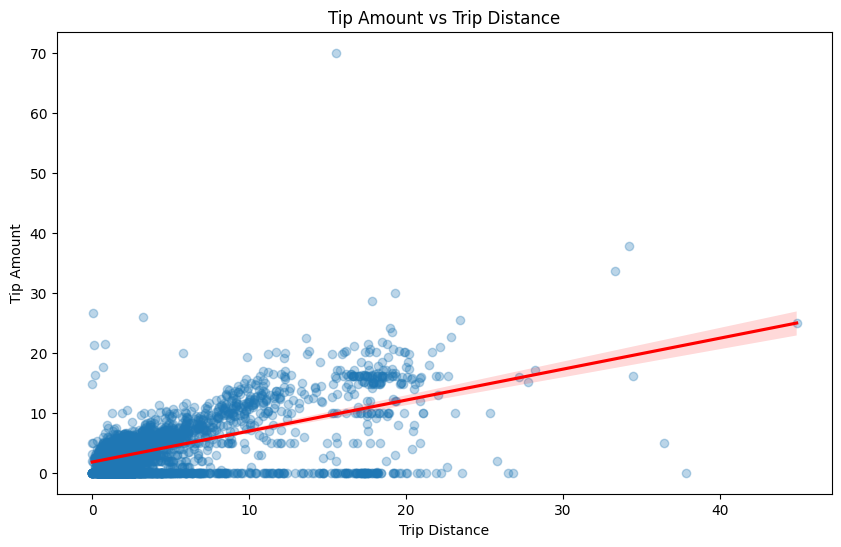

Correlation between Tip Amount and Distance: 0.57


In [ ]:
# Show relationship between tip and trip distance
plt.figure(figsize=(10, 6))
sns.regplot(data=df_filtered.sample(5000), x='trip_distance', y='tip_amount', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Tip Amount vs Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.show()

corr_tip_dist = df[['tip_amount', 'trip_distance']].corr().iloc[0,1]
print(f'Correlation between Tip Amount and Distance: {corr_tip_dist:.2f}')

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

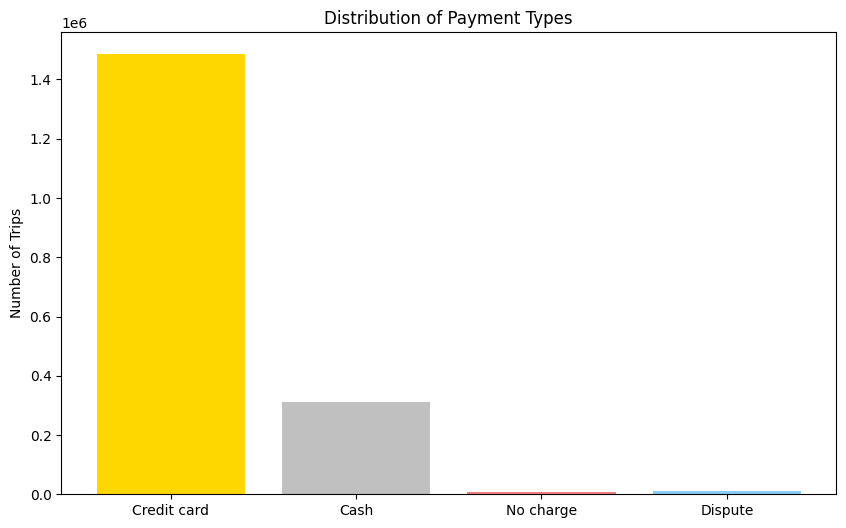

Payment Type Percentages:
payment_type
1    81.814546
2    17.118402
4     0.682850
3     0.384203
Name: proportion, dtype: float64


In [ ]:
# Analyse the distribution of different payment types (payment_type).
plt.figure(figsize=(10, 6))
payment_counts = df_filtered['payment_type'].value_counts().sort_index()
payment_labels = ['Credit card', 'Cash', 'No charge', 'Dispute']
plt.bar(payment_labels, payment_counts, color=['gold', 'silver', 'lightcoral', 'lightskyblue'])
plt.title('Distribution of Payment Types')
plt.ylabel('Number of Trips')
plt.show()

print("Payment Type Percentages:")
print(df_filtered['payment_type'].value_counts(normalize=True) * 100)

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import geopandas as gpd

# Path to the shapefile in the provided drive structure
shapefile_path = '/content/drive/MyDrive/upgrad/C1MA-EDA/data_NYC_Taxi/taxi_zones/taxi_zones.shp'

# Read the shapefile using geopandas
zones = gpd.read_file(shapefile_path)
display(zones.head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

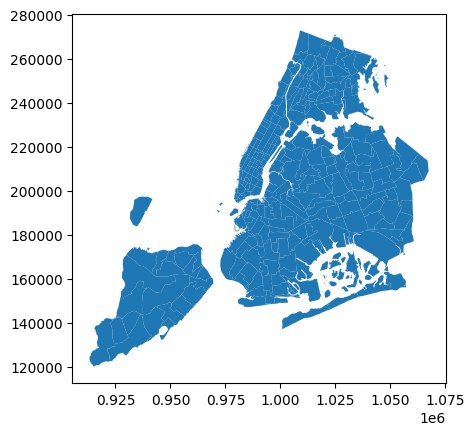

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

Zones merged with trip counts.


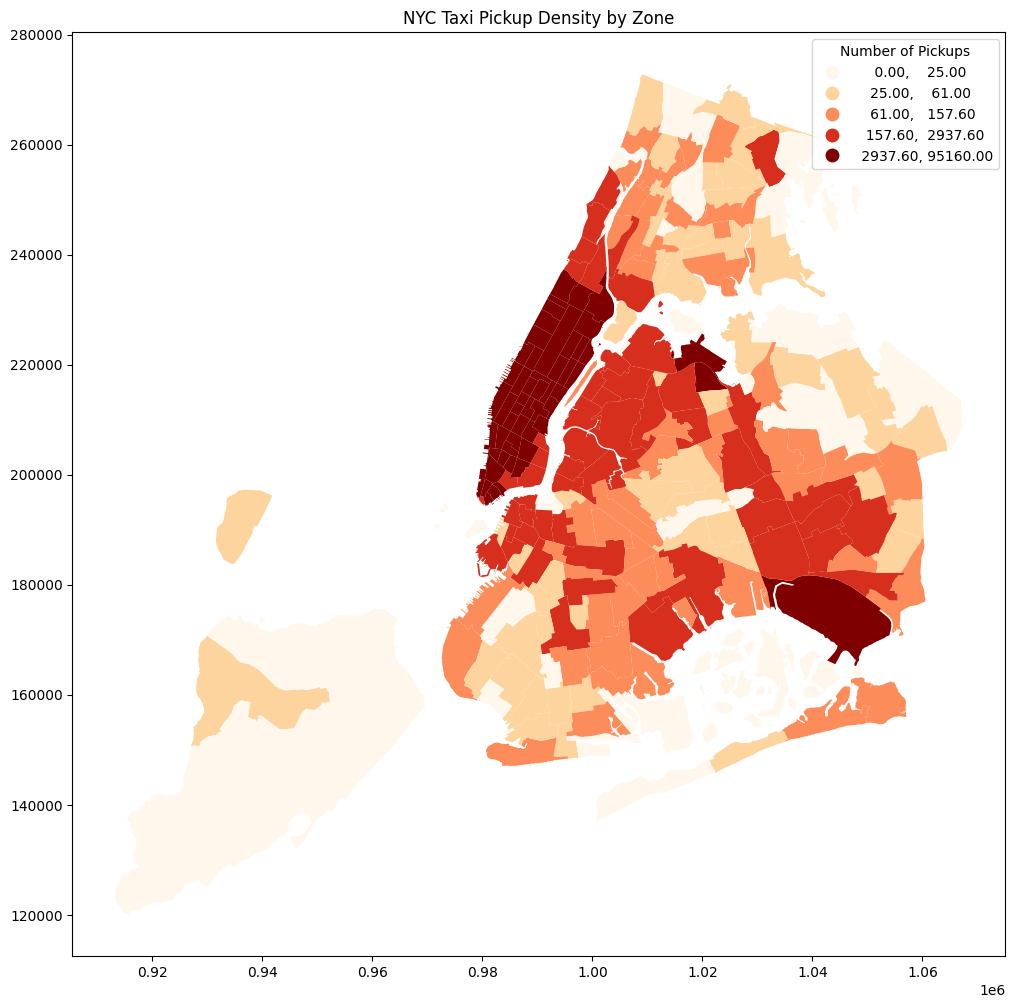

In [ ]:
# Merge zones and trip records using locationID and PULocationID
# First, calculate trip counts per zone
trip_counts = df_filtered['PULocationID'].value_counts().reset_index()
trip_counts.columns = ['LocationID', 'trip_count']

# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trip_counts, on='LocationID', how='left')
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)

print("Zones merged with trip counts.")
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
zones_with_trips.plot(column='trip_count', ax=ax, legend=True,
                      cmap='OrRd', scheme='quantiles', k=5,
                      legend_kwds={'title': 'Number of Pickups'})
plt.title('NYC Taxi Pickup Density by Zone')
plt.show()

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trip_counts = df_filtered.groupby('PULocationID').size().reset_index(name='trip_count')
print("Total number of trips per location ID:")
display(trip_counts.head())



Total number of trips per location ID:


,PULocationID,trip_count
0,1,60
1,2,2
2,3,37
3,4,1831
4,5,12


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trip_counts, left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)
print("Zones merged with trip counts.")




Zones merged with trip counts.


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

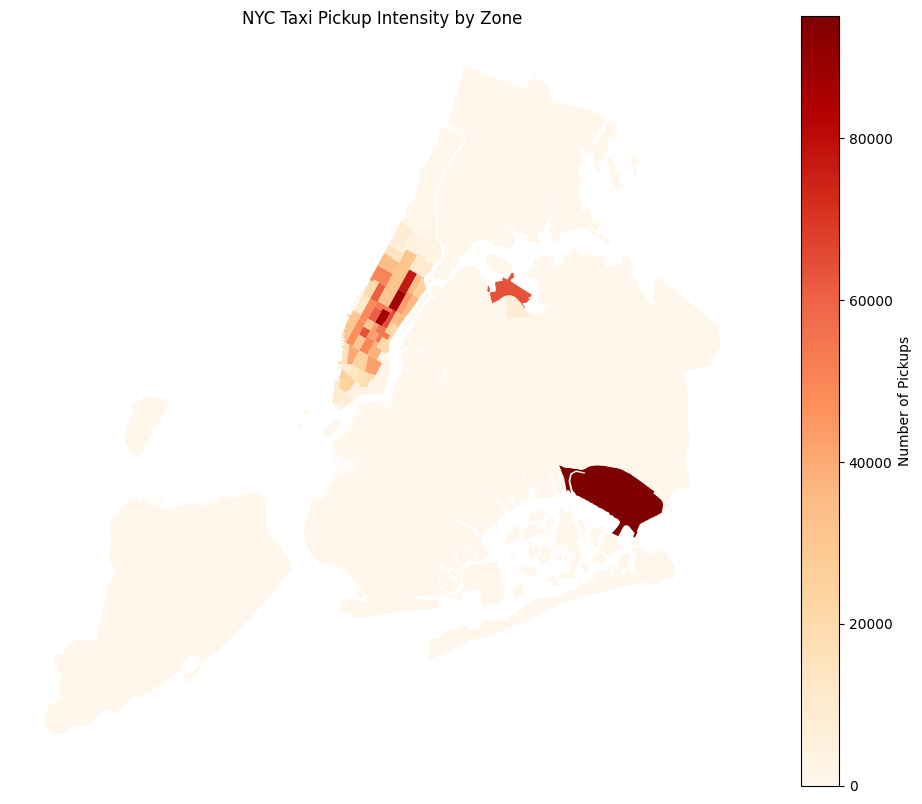

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_with_trips.plot(column='trip_count',
                      ax=ax,
                      legend=True,
                      cmap='OrRd',
                      legend_kwds={'label': "Number of Pickups", 'orientation': "vertical"})
plt.title('NYC Taxi Pickup Intensity by Zone')
plt.axis('off')
plt.show()

In [ ]:
# Display the zones DF sorted by the number of trips
display(zones_with_trips[['zone', 'borough', 'trip_count']].sort_values(by='trip_count', ascending=False).head(10))

,zone,borough,trip_count
131,JFK Airport,Queens,95160.0
236,Upper East Side South,Manhattan,86637.0
160,Midtown Center,Manhattan,85622.0
235,Upper East Side North,Manhattan,77290.0
161,Midtown East,Manhattan,65373.0
137,LaGuardia Airport,Queens,63769.0
185,Penn Station/Madison Sq West,Manhattan,63195.0
229,Times Sq/Theatre District,Manhattan,60920.0
141,Lincoln Square East,Manhattan,60680.0
169,Murray Hill,Manhattan,54202.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


### Findings from general analysis

Based on the temporal, financial, and geographical analyses, the following insights can be derived:

*   **Busiest Hours, Days, and Months:**
    *   **Hourly:** Taxi pickups are highest between 5 PM and 7 PM, with 6 PM being the peak hour. There is also significant activity during daytime hours (10 AM to 4 PM). Early morning hours (1 AM to 5 AM) show the lowest pickup activity.
    *   **Daily:** Mid-week days, particularly Wednesday and Thursday, exhibit the highest number of taxi pickups. Monday tends to have the fewest trips, while weekends show moderate activity.
    *   **Monthly:** October records the highest number of taxi pickups, followed by March, May, and December. February and August are generally the quietest months for pickups.

*   **Trends in Revenue Collected:**
    *   Monthly revenue fluctuates throughout the year, with notable peaks in May and October, and dips in February and August. The overall trend indicates seasonal variations in total revenue.

*   **Trends in Quarterly Revenue:**
    *   Q2 (April-June) and Q4 (October-December) contribute equally to the highest proportion of the annual revenue, each accounting for 26.7%. Q1 (January-March) makes up 23.6%, while Q3 (July-September) is the lowest with 22.9% of the revenue.

*   **How Fare Depends on Trip Distance, Trip Duration, and Passenger Counts:**
    *   **Trip Distance vs. Fare Amount:** There is a weak to moderate positive correlation (0.1560) between trip distance and fare amount, indicating that longer trips generally incur higher fares, but other factors also play a significant role.
    *   **Trip Duration vs. Fare Amount:** The correlation between trip duration and fare amount is very low (0.0456), suggesting that trip duration alone does not have a strong linear impact on the fare.
    *   **Passenger Count vs. Fare Amount:** The correlation between passenger count and fare amount is extremely low (0.01), and the median fare is similar across different passenger counts, implying that the number of passengers has minimal effect on the fare amount.

*   **How Tip Amount Depends on Trip Distance:**
    *   A moderate positive correlation (0.57) exists between tip amount and trip distance, suggesting that passengers tend to tip more for longer trips.

*   **Busiest Zones:**
    *   The highest taxi pickup activity is concentrated in key areas such as Upper East Side South, Midtown East, Upper East Side North, Murray Hill, Times Sq/Theatre District, Lincoln Square East, JFK Airport, and LaGuardia Airport. These zones represent high-demand areas for taxi services.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day
route_stats = df_filtered[df_filtered['trip_duration'] > 0].copy()
route_stats['speed_mph'] = route_stats['trip_distance'] / (route_stats['trip_duration'] / 60)

# Group by route and hour to find average speed
route_efficiency = route_stats.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])['speed_mph'].mean().reset_index()

# Identify the 10 slowest routes with at least some minimum distance
slow_routes = route_efficiency[route_efficiency['speed_mph'] > 0].sort_values(by='speed_mph').head(10)
print("Top 10 Slowest Routes (Bottlenecks):")
display(slow_routes)

Top 10 Slowest Routes (Bottlenecks):


,PULocationID,DOLocationID,pickup_hour,speed_mph
103968,232,65,13,0.005324
116714,243,264,17,0.007772
62306,142,142,5,0.023770
122304,258,258,1,0.026230
34180,100,7,8,0.039470
6661,40,65,21,0.046848
40333,113,235,22,0.048105
90617,194,194,16,0.048913
9996,45,45,10,0.059484
128464,264,168,23,0.071573


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Number of trips per hour:
pickup_hour
18    128277
17    122527
19    115176
15    113293
16    113158
14    110513
13    103141
20    102715
21    102439
12    100001
22     94533
11     92126
10     84813
9      77586
23     74227
8      67743
0      50601
7      48605
1      33814
6      24215
2      22210
3      14442
5       9853
4       9179
Name: count, dtype: int64


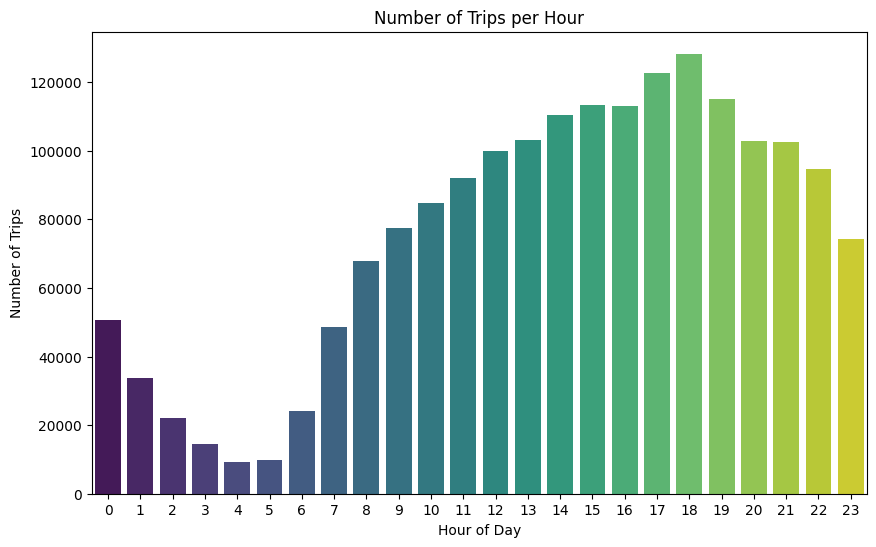

The busiest hour is 18 with 128277 trips.


In [ ]:
# Visualise the number of trips per hour and find the busiest hour
busy_hours = df_filtered['pickup_hour'].value_counts().sort_values(ascending=False)
print("Number of trips per hour:")
print(busy_hours)

# calculate the number of trips at each hour of the day and visualise them.
plt.figure(figsize=(10, 6))
sns.barplot(x=busy_hours.index, y=busy_hours.values, palette='viridis')
plt.title('Number of Trips per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

# Find the busiest hour and show the number of trips for that hour.
busiest_hour = busy_hours.idxmax()
print(f"The busiest hour is {busiest_hour} with {busy_hours.max()} trips.")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips
sample_fraction = 0.05
busy_hours = df_filtered['pickup_hour'].value_counts().sort_values(ascending=False).head(5)
actual_trips_est = busy_hours / sample_fraction
print("Estimated actual trip counts for the 5 busiest hours:")
print(actual_trips_est)

Estimated actual trip counts for the 5 busiest hours:
pickup_hour
18    2565540.0
17    2450540.0
19    2303520.0
15    2265860.0
16    2263160.0
Name: count, dtype: float64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

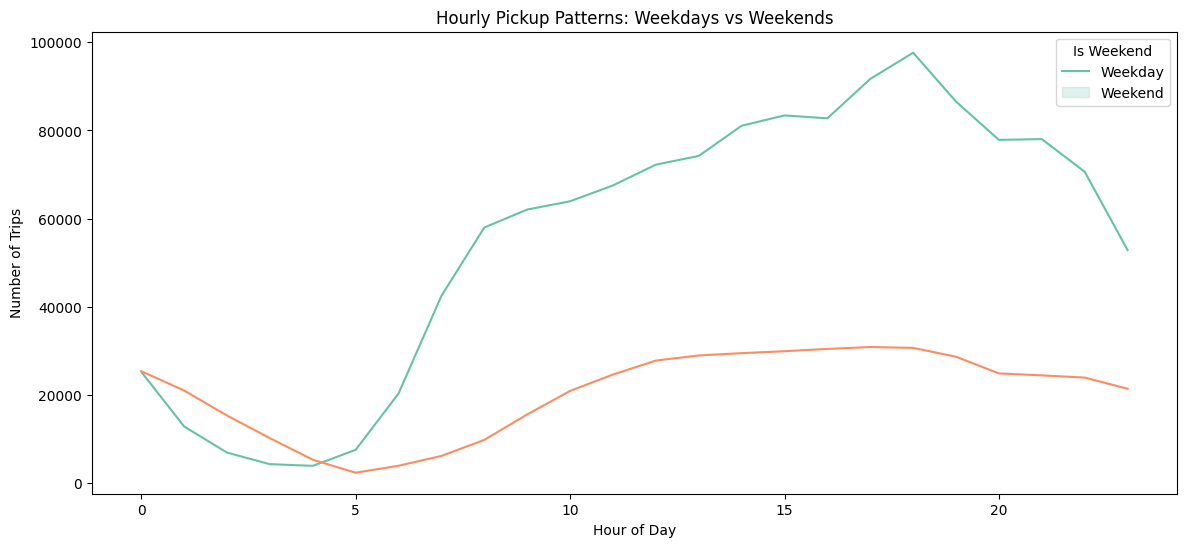

In [ ]:
# Compare traffic trends for the week days and weekends
df_filtered['is_weekend'] = df_filtered['tpep_pickup_datetime'].dt.dayofweek >= 5
traffic_comparison = df_filtered.groupby(['pickup_hour', 'is_weekend']).size().reset_index(name='trip_count')

plt.figure(figsize=(14, 6))
sns.lineplot(data=traffic_comparison, x='pickup_hour', y='trip_count', hue='is_weekend', palette='Set2')
plt.title('Hourly Pickup Patterns: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.legend(title='Is Weekend', labels=['Weekday', 'Weekend'])
plt.show()

**What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?**

From the hourly pickup patterns: Weekdays show a clear morning and evening peak (6-9 AM, 5-7 PM), with lower early morning demand. Weekends have a more gradual increase in demand, peaking in the late afternoon/early evening (3-7 PM), with generally lower overall volume than weekday peaks.

Identifying these patterns allows for:
1.  **Optimal Resource Allocation:** Deploying more taxis during peak demand and scaling back during quiet periods to improve efficiency and reduce wait times.
2.  **Dynamic Pricing/Incentives:** Implementing surge pricing during busy hours to attract drivers and balance demand, or promotions during quiet times to stimulate demand.
3.  **Better Driver Management:** Scheduling drivers to align with demand, reducing idle time and increasing earnings.
4.  **Strategic Planning:** Utilizing low-demand periods for vehicle maintenance or driver training, minimizing operational disruption.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones
top_pickups = df_filtered['PULocationID'].value_counts().head(10)
top_dropoffs = df_filtered['DOLocationID'].value_counts().head(10)

print("Top 10 Pickup Zones:")
print(top_pickups)
print("\nTop 10 Dropoff Zones:")
print(top_dropoffs)


Top 10 Pickup Zones:
PULocationID
132    95160
237    86637
161    85622
236    77290
162    65373
138    63769
186    63195
230    60920
142    60680
170    54202
Name: count, dtype: int64

Top 10 Dropoff Zones:
DOLocationID
236    81057
237    77304
161    71350
230    56024
170    54039
162    51999
142    51309
239    51092
141    48309
68     46100
Name: count, dtype: int64


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_dropoff_ratios = (df_filtered['PULocationID'].value_counts() / df_filtered['DOLocationID'].value_counts()).sort_values(ascending=False)
print("Top 10 Pickup/Dropoff Ratios:")
print(pickup_dropoff_ratios.head(10))
print("\nBottom 10 Pickup/Dropoff Ratios:")
print(pickup_dropoff_ratios.tail(10))



Top 10 Pickup/Dropoff Ratios:
70     9.228443
132    4.911230
138    2.916488
186    1.585225
114    1.376045
43     1.375695
249    1.327073
162    1.257197
161    1.200028
100    1.192618
Name: count, dtype: float64

Bottom 10 Pickup/Dropoff Ratios:
257    0.034392
27     0.025641
1      0.011619
30          NaN
99          NaN
109         NaN
176         NaN
199         NaN
221         NaN
245         NaN
Name: count, dtype: float64


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_hours = (df_filtered['pickup_hour'] >= 23) | (df_filtered['pickup_hour'] <= 4)
night_pickups = df_filtered[night_hours]['PULocationID'].value_counts().head(10)
night_dropoffs = df_filtered[night_hours]['DOLocationID'].value_counts().head(10)
print("Top 10 Night Pickup Zones:")
print(night_pickups)
print("\nTop 10 Night Dropoff Zones:")
print(night_dropoffs)



Top 10 Night Pickup Zones:
PULocationID
79     15263
132    13196
249    12295
48      9730
148     9471
114     8673
230     7709
186     6181
164     5910
138     5906
Name: count, dtype: int64

Top 10 Night Dropoff Zones:
DOLocationID
79     8170
48     6575
170    6028
107    5585
68     5492
141    5091
249    4846
263    4845
148    4269
229    4250
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)
night_hours = (df_filtered['pickup_hour'] >= 23) | (df_filtered['pickup_hour'] <= 4)
df_night = df_filtered[night_hours]

# Find the revenue share for nighttime and daytime hours
night_revenue_share = (df_night['fare_amount'].sum() / df_filtered['fare_amount'].sum()) * 100
day_revenue_share = 100 - night_revenue_share
print(f"Revenue Share for Nighttime Hours: {night_revenue_share:.2f}%")
print(f"Revenue Share for Daytime Hours: {day_revenue_share:.2f}%")


Revenue Share for Nighttime Hours: 11.29%
Revenue Share for Daytime Hours: 88.71%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Average fare per mile per passenger
df_filtered['fare_per_mile'] = df_filtered['fare_amount'] / df_filtered['trip_distance'].replace(0, np.nan)
df_filtered['fare_per_mile_per_passenger'] = df_filtered['fare_per_mile'] / df_filtered['passenger_count']
avg_fare_metrics = df_filtered.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()
print("Average fare per mile per passenger:")
display(avg_fare_metrics)

Average fare per mile per passenger:


,fare_per_mile_per_passenger
passenger_count,
1,11.005932
2,6.427124
3,3.908226
4,4.363335
5,1.709614
6,1.350823


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day
df_filtered['pickup_day'] = df_filtered['tpep_pickup_datetime'].dt.day_name()
fare_per_mile_by_day = df_filtered.groupby('pickup_day')['fare_per_mile'].mean()
fare_per_mile_by_hour = df_filtered.groupby('pickup_hour')['fare_per_mile'].mean()
print("Average fare per mile by day of the week:")
print(fare_per_mile_by_day)
print("\nAverage fare per mile by hour of the day:")
print(fare_per_mile_by_hour)

Average fare per mile by day of the week:
pickup_day
Friday       10.906075
Monday       10.982012
Saturday     10.921498
Sunday       12.530123
Thursday     11.263672
Tuesday      12.149909
Wednesday    11.112734
Name: fare_per_mile, dtype: float64

Average fare per mile by hour of the day:
pickup_hour
0     10.526099
1     11.273357
2      9.942036
3     10.870866
4     14.004000
5     14.241165
6     11.204280
7     10.284211
8     10.392872
9     10.393090
10    13.117128
11    10.954145
12    12.060776
13    11.997917
14    11.628768
15    12.478519
16    13.912929
17    11.962624
18    11.541822
19    11.615659
20     9.569303
21     9.519266
22    10.154484
23    10.695948
Name: fare_per_mile, dtype: float64


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

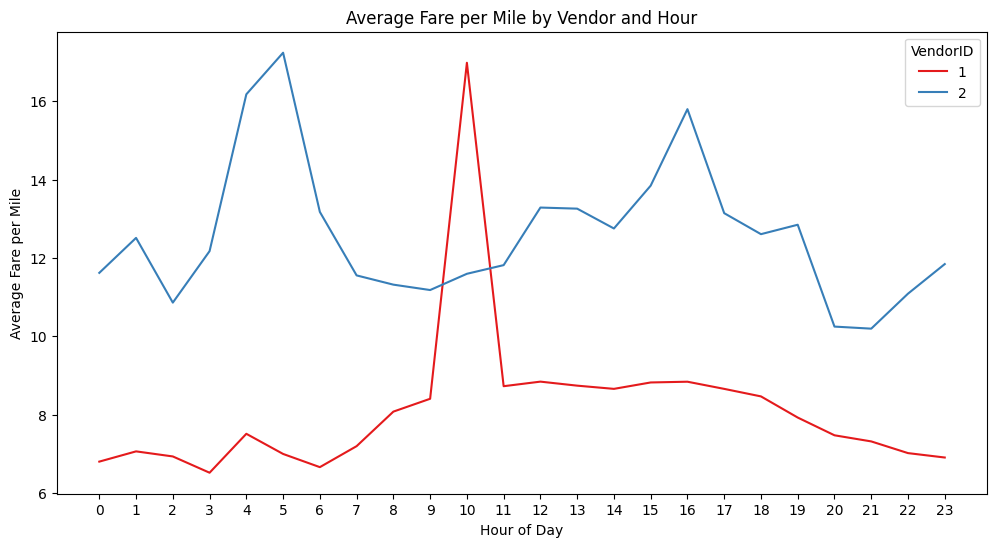

In [ ]:
# Compare fare per mile for different vendors
df_filtered['fare_per_mile'] = df_filtered['fare_per_mile'].replace([np.inf, -np.inf], np.nan)
vendor_comparison_data = df_filtered.dropna(subset=['fare_per_mile'])
vendor_comparison = vendor_comparison_data.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=vendor_comparison, x='pickup_hour', y='fare_per_mile', hue='VendorID', palette='Set1')
plt.title('Average Fare per Mile by Vendor and Hour')
plt.ylabel('Average Fare per Mile')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 24))
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Tiered distance analysis
def get_tier(dist):
    if dist <= 2: return 'Short (0-2m)'
    elif dist <= 5: return 'Medium (2-5m)'
    else: return 'Long (>5m)'

df_filtered['distance_tier'] = df_filtered['trip_distance'].apply(get_tier)
tiered_vendor = df_filtered.groupby(['distance_tier', 'VendorID'])['fare_per_mile'].mean().unstack()
print("Average fare per mile by vendor and distance tier:")
display(tiered_vendor)

Average fare per mile by vendor and distance tier:


VendorID,1,2
distance_tier,,
Long (>5m),4.425264,4.503213
Medium (2-5m),6.381275,6.549310
Short (0-2m),10.673158,17.912767


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

Average tip percentage by passenger count:
passenger_count
1    20.903074
2    19.727144
3    19.024955
4    17.437263
5    20.509690
6    20.596898
Name: tip_percentage, dtype: float64


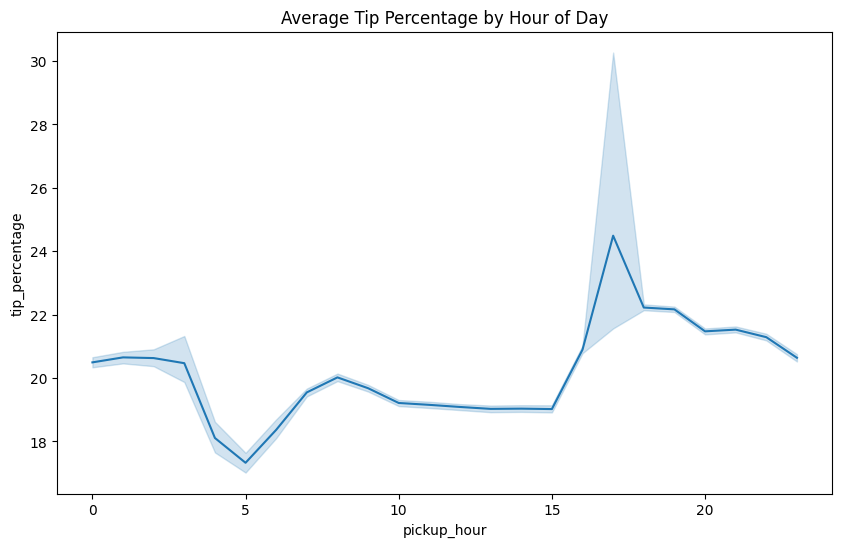

In [ ]:
# Analyze tip percentages
df_filtered['tip_percentage'] = (df_filtered['tip_amount'] / df_filtered['fare_amount']) * 100
print("Average tip percentage by passenger count:")
print(df_filtered.groupby('passenger_count')['tip_percentage'].mean())

plt.figure(figsize=(10,6))
sns.lineplot(data=df_filtered, x='pickup_hour', y='tip_percentage')
plt.title('Average Tip Percentage by Hour of Day')
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
low_tip_trips = df_filtered[df_filtered['tip_percentage'] < 10]
high_tip_trips = df_filtered[df_filtered['tip_percentage'] > 25]

#  try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours
low_tip_stats = low_tip_trips[['trip_distance', 'passenger_count', 'tip_percentage']].describe()
high_tip_stats = high_tip_trips[['trip_distance', 'passenger_count', 'tip_percentage']].describe()

print("Statistics for trips with low tip percentage:")
display(low_tip_stats)
print("\nStatistics for trips with high tip percentage:")
display(high_tip_stats)



Statistics for trips with low tip percentage:


,trip_distance,passenger_count,tip_percentage
count,475436.000000,475436.000000,475436.000000
mean,3.884177,1.427662,1.073542
std,5.192739,0.910048,2.644875
min,0.000000,1.000000,0.000000
25%,1.050000,1.000000,0.000000
50%,1.870000,1.000000,0.000000
75%,4.000000,2.000000,0.000000
max,204.860000,6.000000,9.991942



Statistics for trips with high tip percentage:


,trip_distance,passenger_count,tip_percentage
count,815131.000000,815131.000000,815131.000000
mean,2.296185,1.363370,32.565548
std,2.903093,0.861541,388.004844
min,0.000000,1.000000,25.005501
25%,0.920000,1.000000,27.133028
50%,1.420000,1.000000,30.000000
75%,2.230000,1.000000,33.978495
max,72.280000,6.000000,350000.000000


Tipping Behaviour Summary: factors like trip distance and time of day appear to influence tipping behavior. Higher tip percentages are observed during afternoon hours and potentially on shorter trips. The passenger_count doesn't seem to be a strong differentiator between low and high tipping behavior based on these statistics alone.

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

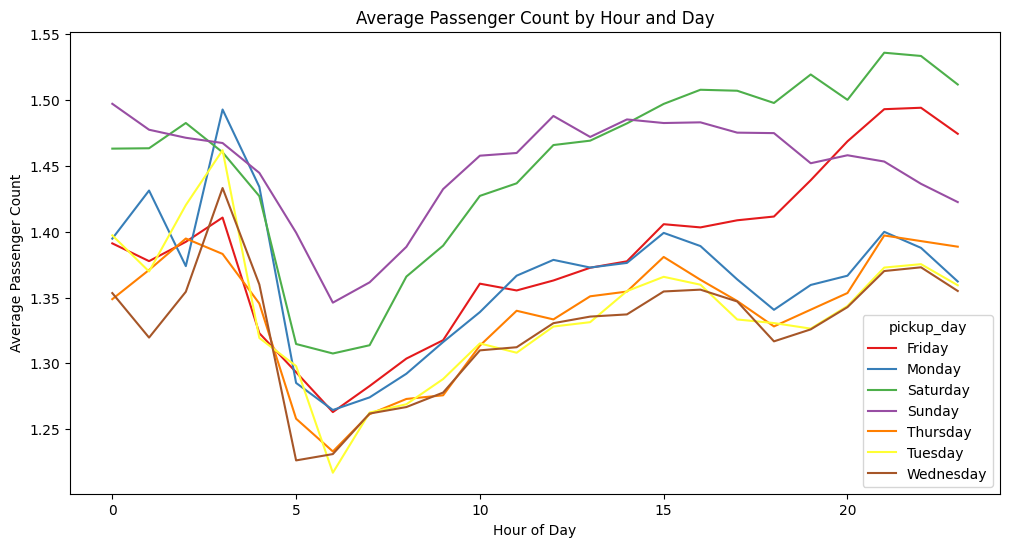

In [ ]:
# See how passenger count varies across hours and days
passenger_count_by_hour = df_filtered.groupby(['pickup_hour', 'pickup_day'])['passenger_count'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=passenger_count_by_hour, x='pickup_hour', y='passenger_count', hue='pickup_day', palette='Set1')
plt.title('Average Passenger Count by Hour and Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passenger Count')
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

Passenger Count by Zone:


,PULocationID,passenger_count
0,1,1.316667
1,2,1.000000
2,3,1.000000
3,4,1.432004
4,5,1.000000
...,...,...
250,261,1.544549
251,262,1.329311
252,263,1.337622
253,264,1.347473


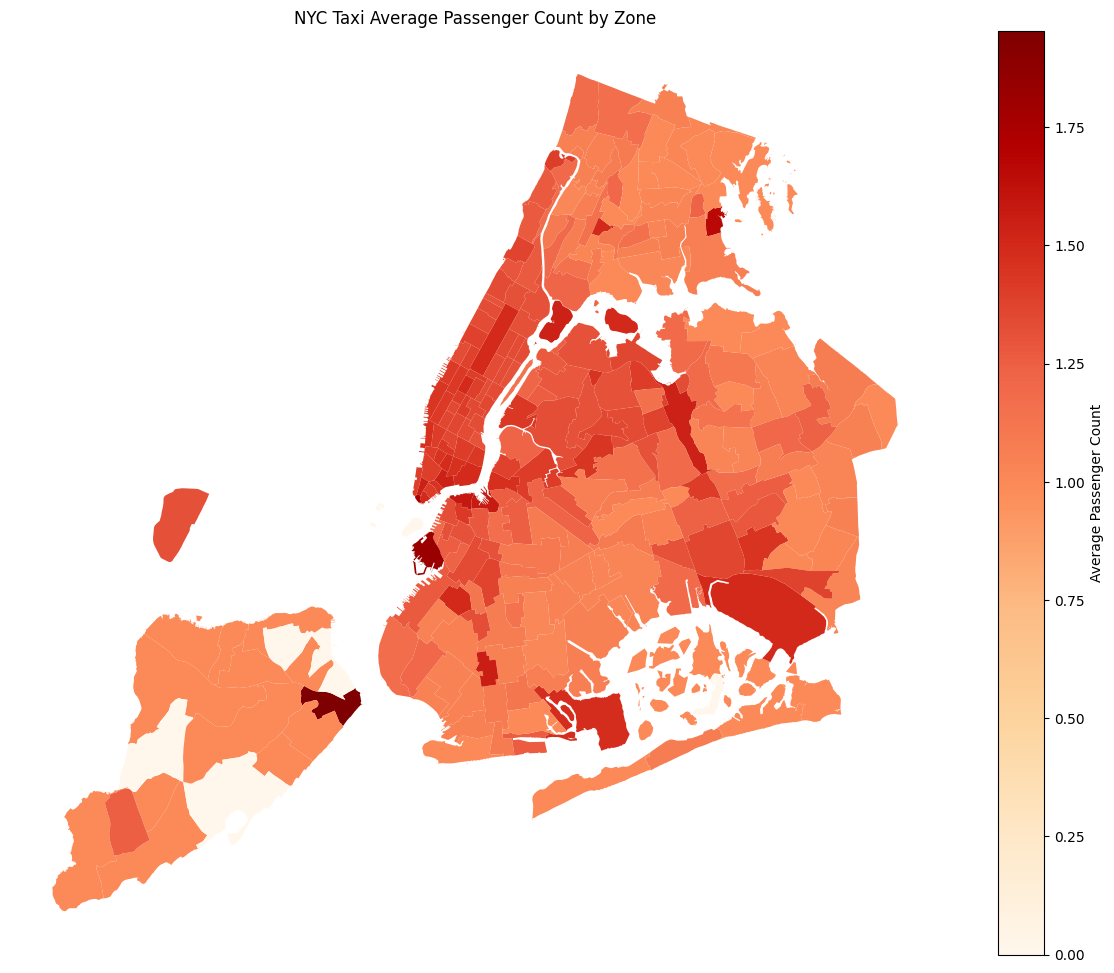

In [ ]:
# How does passenger count vary across zones
passenger_count_by_zone = df_filtered.groupby('PULocationID')['passenger_count'].mean().reset_index()
print("Passenger Count by Zone:")
display(passenger_count_by_zone)

passenger_count_by_zone.rename(columns={'PULocationID': 'LocationID'}, inplace=True)

if 'passenger_count' in zones_with_trips.columns:
    zones_with_trips = zones_with_trips.drop(columns=['passenger_count'])

zones_with_trips = zones_with_trips.merge(passenger_count_by_zone, on='LocationID', how='left')
zones_with_trips['passenger_count'] = zones_with_trips['passenger_count'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(15, 12))
zones_with_trips.plot(column='passenger_count',
                      ax=ax,
                      legend=True,
                      cmap='OrRd',
                      legend_kwds={'label': "Average Passenger Count", 'orientation': "vertical"})
plt.title('NYC Taxi Average Passenger Count by Zone')
plt.axis('off')
plt.show()

In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones_with_trips['avg_passenger_count'] = zones_with_trips['passenger_count'] / zones_with_trips['trip_count']
display(zones_with_trips[['zone', 'borough', 'passenger_count', 'trip_count', 'avg_passenger_count']].head())

,zone,borough,passenger_count,trip_count,avg_passenger_count
0,Newark Airport,EWR,1.316667,60.0,0.021944
1,Jamaica Bay,Queens,1.000000,2.0,0.500000
2,Allerton/Pelham Gardens,Bronx,1.000000,37.0,0.027027
3,Alphabet City,Manhattan,1.432004,1831.0,0.000782
4,Arden Heights,Staten Island,1.000000,12.0,0.083333


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

extra applied in 62.20% of trips.
mta_tax applied in 99.34% of trips.
improvement_surcharge applied in 99.98% of trips.
congestion_surcharge applied in 92.76% of trips.


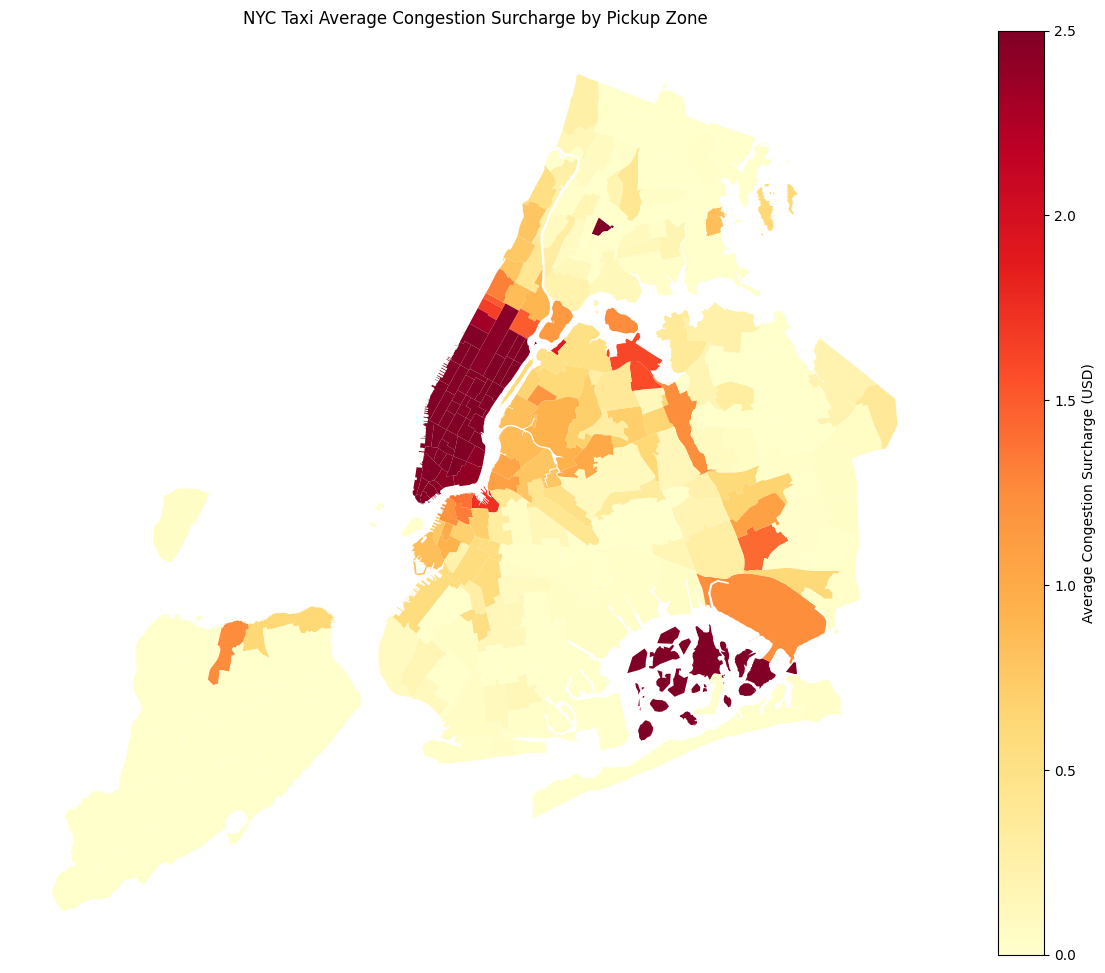

In [ ]:
# Frequency of surcharges
surcharges = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge']
for s in surcharges:
    freq = (df_filtered[s] > 0).mean() * 100
    print(f"{s} applied in {freq:.2f}% of trips.")

avg_congestion_surcharge_by_zone = df_filtered.groupby('PULocationID')['congestion_surcharge'].mean().reset_index()
avg_congestion_surcharge_by_zone.rename(columns={'PULocationID': 'LocationID'}, inplace=True)

if 'congestion_surcharge' in zones_with_trips.columns:
    zones_with_trips = zones_with_trips.drop(columns=['congestion_surcharge'])

zones_with_trips = zones_with_trips.merge(avg_congestion_surcharge_by_zone, on='LocationID', how='left')
zones_with_trips['congestion_surcharge'] = zones_with_trips['congestion_surcharge'].fillna(0)

# Plotting the map for average congestion surcharge
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
zones_with_trips.plot(column='congestion_surcharge',
                      ax=ax,
                      legend=True,
                      cmap='YlOrRd',
                      legend_kwds={'label': "Average Congestion Surcharge (USD)", 'orientation': "vertical"})
plt.title('NYC Taxi Average Congestion Surcharge by Pickup Zone')
plt.axis('off')
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

### What We Learned About How Taxis Work (Operational Efficiency)

*   **Slow Roads (Traffic Jams):** We found some roads where taxis move very slowly at certain times. This means there are traffic jams or the best way to drive is not clear. These slow roads are important to fix, especially in the afternoon and evening.
    *   *Example Slow Roads:* Some roads had very slow speeds, like 0.005 to 0.07 miles per hour. We need to look at these areas closely.

*   **Busy Times for Taxis:** We saw that many people take taxis at specific hours.
    *   The busiest time is **6 PM (18:00)**, with about 2.57 million trips. Other busy times are 5 PM, 7 PM, 3 PM, and 4 PM.
    *   More people start taking taxis from 6 AM, it gets very busy from 4 PM to 7 PM, and then slowly fewer people use taxis until 5 AM.

*   **Busy Times on Weekdays vs. Weekends:**
    *   **Weekdays:** Taxis are busy in the morning (7-9 AM) and much busier in the evening (5-7 PM). More people use taxis on weekdays than on weekends.
    *   **Weekends:** Taxis get busy later in the day, from 3 PM to 7 PM. Not as many people use taxis on weekends compared to busy weekdays.

*   **Most Popular Areas for Pickups and Dropoffs:**
    *   **Top 10 Pickup Areas:** Many people get taxis from places like Manhattan (Upper East Side, Midtown East) and big places like JFK Airport.
    *   **Top 10 Dropoff Areas:** Taxis also drop off many people in these same busy areas. But drop-offs happen in more different places than pickups.

*   **How Many Pickups vs. Dropoffs in Each Area:** Some areas have many more pickups than dropoffs, or the other way around.
    *   **Many Pickups, Few Dropoffs:** Areas with high ratios (like LocationID 70 with 9.23 pickups for every 1 dropoff, or JFK Airport) are where many people start their trips. Taxis drop someone off and quickly find a new passenger.
    *   **Few Pickups, Many Dropoffs:** Areas with low ratios (like LocationID 257 with 0.03 pickups for every 1 dropoff) are mostly where people finish their trips, like homes or places with less outgoing traffic.

*   **Taxis at Night (11 PM - 5 AM):** Some areas are busy even very late or very early.
    *   **Top Night Pickup Areas:** These are often places where people go out at night (like LocationID 79, 132, 249).
    *   **Top Night Dropoff Areas:** Similarly, these are where people go home late (like LocationID 79, 48, 170).
    *   **Money from Night Trips:** About 11.29% of all money from fares comes from night trips (11 PM - 5 AM). The rest, 88.71%, comes from daytime trips. This means night trips are important for making money, maybe because they are longer or cost more late at night.

### Detailed Findings from Pricing Strategy Analysis

*   **Average Fare Per Mile Per Passenger:** The average fare per mile per passenger varies significantly with the number of passengers.
    *   Single-passenger trips have the highest fare per mile per passenger (~11.01 USD/mile/passenger), indicating they are the most 'profitable' per individual passenger carried.
    *   As passenger count increases, the fare per mile per passenger generally decreases (e.g., 6 passengers: ~1.35 USD/mile/passenger). This suggests that while total fare might increase with more passengers, the individual cost burden per passenger is reduced.

*   **Average Fare Per Mile by Hour and Day:**
    *   **By Day:** Sundays and Tuesdays tend to have higher average fare per mile (approx. 12.53 USD/mile and 12.15 USD/mile respectively), possibly indicating higher demand or longer average trip distances on these days. Friday and Monday have slightly lower averages.
    *   **By Hour:** Peaks in average fare per mile are observed in the early morning (4 AM - 5 AM, approx. 14.00-14.24 USD/mile) and late afternoon (3 PM - 4 PM, approx. 12.48-13.91 USD/mile). The high early morning rates could be due to airport runs or lack of alternative transportation, leading to less price sensitivity.

*   **Average Fare Per Mile by Vendor and Hour:**
    *   There is a clear difference in pricing strategy and/or customer base between `VendorID` 1 and `VendorID` 2.
    *   `VendorID` 2 consistently shows a higher average fare per mile throughout most hours of the day, particularly peaking in the early morning (4-5 AM) and mid-afternoon (3-4 PM).
    *   `VendorID` 1 generally has lower average fares per mile, with a noticeable spike around 10 AM, suggesting a possible different operational focus or customer segment.

*   **Tiered Distance Analysis (Average Fare Per Mile by Vendor and Distance Tier):**
    *   **Short Trips (0-2 miles):** Show the highest average fare per mile for both vendors, especially for `VendorID` 2 (approx. 17.91 USD/mile). This could be due to minimum fare charges that disproportionately affect short distances.
    *   **Medium Trips (2-5 miles):** The fare per mile decreases significantly for both vendors compared to short trips (e.g., `VendorID` 2 is approx. 6.55 USD/mile). Competition or standard rates might play a role here.
    *   **Long Trips (>5 miles):** The fare per mile is the lowest, around 4.43-4.50 USD/mile, which is expected as fixed costs are spread over longer distances, and potentially due to less competitive pricing at longer distances or different passenger expectations.


### Detailed Findings from Customer Experience and Other Factors

*   **Average Tip Percentages:**
    *   **By Passenger Count:** The average tip percentage is relatively consistent across different passenger counts, ranging from approximately 17.4% (for 4 passengers) to 20.9% (for 1 passenger). This indicates that the number of passengers does not significantly influence tipping behavior.
    *   **By Hour of Day:** Tip percentages show some variation by hour. There's a notable dip in average tip percentage during early morning hours (2 AM - 5 AM) and an increase towards the late afternoon/early evening (4 PM - 7 PM), with a significant peak around 5 PM (17:00). This peak might correlate with peak demand times or potentially more satisfied customers during these hours.
    *   **Comparison of Low vs. High Tip Trips:**
        *   **Low Tip Trips (tip percentage < 10%):** Characterized by a higher mean `trip_distance` (3.88 miles) and generally lower average `passenger_count` (1.43). The median `tip_percentage` for these trips is 0%, suggesting a large number of trips with no tips.
        *   **High Tip Trips (tip percentage > 25%):** Show a lower mean `trip_distance` (2.30 miles) compared to low-tip trips, and a slightly lower average `passenger_count` (1.36). The median `tip_percentage` is 30%. This implies that passengers tend to give higher tip percentages on shorter trips, contrary to the overall correlation where total tip amount correlates with distance.
        *   **Factors Leading to Low Tip Percentages:** Trips with low or zero tips are often associated with longer distances and could be cash payments (where tips are not recorded) or passengers who are less inclined to tip.

*   **Variation of Passenger Count:**
    *   **Across Hours and Days of the Week:** Average passenger count is relatively stable, hovering around 1.3 to 1.5 passengers per trip. Weekends (Saturday and Sunday) generally show slightly higher average passenger counts throughout the day compared to weekdays, suggesting more group travel. Weekday mornings and late nights often have lower average passenger counts.
    *   **Across Zones:** The average passenger count also varies by zone. Some zones, particularly those associated with airports or tourist attractions, might have slightly higher average passenger counts, indicating more group travel to/from these locations.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

1.  **Dynamic Taxi Allocation for Peak Hours:** Increase the availability of taxis in high-demand zones (Midtown, Upper East Side, JFK Airport) during peak hours (5 PM - 8 PM on weekdays) and weekend afternoons (3 PM - 7 PM) to minimize passenger wait times and capitalize on high revenue opportunities.
2.  **Route Optimization for Bottleneck Areas:** Implement real-time traffic monitoring and navigation systems to suggest alternative routes to drivers, especially for identified slow routes and during rush hours, to reduce trip duration and improve efficiency.
3.  **Strategic Positioning for Night Shifts:** During night hours (11 PM - 5 AM), concentrate taxi allocation in identified night-time pickup hotspots (e.g., entertainment districts, specific residential areas) to serve late-night demand and capture potentially higher fares.
4.  **Leverage Pickup/Dropoff Ratios:** For zones with very high pickup-to-dropoff ratios (trip generators), strategically position idle taxis nearby to reduce deadhead mileage and quickly serve new passengers. For zones with very low ratios (trip sinks), encourage drivers to move to more active areas after dropping off passengers.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

1.  **More Taxis When Many People Need Them:** We should put more taxis in busy areas (like Midtown, Upper East Side, JFK Airport) during the busiest times (5 PM - 8 PM on weekdays) and on weekend afternoons (3 PM - 7 PM). This will help people get taxis faster and we can earn more money.
2.  **Help Drivers with Traffic:** We should use technology to show drivers the best ways to go, especially when there are traffic jams or on slow roads. This will make trips faster and better.
3.  **Taxis for Night People:** Late at night (11 PM - 5 AM), we should make sure there are enough taxis in the areas where people often get pickups at night. This way, we can serve people who need rides late.
4.  **Smart Taxi Parking:** In areas where many people get picked up (more pickups than dropoffs, like airports), we should have empty taxis waiting nearby. This helps taxis not drive around empty and quickly find new passengers.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

1.  **Special Prices for Short Trips:** We can charge a bit more per mile for very short trips (0-2 miles). This is because short trips sometimes cost more for the taxi company. One company (VendorID 2) already does this.
2.  **Fair Prices for Medium Trips:** For trips between 2 and 5 miles, we should keep prices good so we can compete with other taxi companies. Maybe we can offer a fixed price or a small discount when it's not busy.
3.  **Use Traffic Charges Smartly:** We should make sure to add the traffic charge in busy areas during busy times, like Midtown. This is allowed and helps with revenue. We also need to tell customers about these charges clearly.
4.  **Encourage Card Payments for Tips:** We should make it easy for people to pay with credit cards. People often tip more with cards, and these tips are recorded. This helps drivers earn more and also helps our company.
5.  **Higher Prices for Busy Times:** We can charge more during the busiest hours (like 4-7 PM) and on busy days (Sundays, Tuesdays). People are willing to pay more when they really need a taxi, and this helps us earn more.

# NYC Taxi Trip Data Report: Easy to Understand Version

## Introduction
This report is about looking at New York City Yellow Taxi trip data from 2023. Our goal is to find good ideas to make taxis work better, earn more money, and make customers happier. We loaded the data, cleaned it, and then studied it in different ways: about time, money, and places. We also looked closely at how taxis work, how they charge money, and how customers feel.

## What We Assumed (Our Guesses)
While we did this work, we made some guesses:
*   **Small Part of Data:** We used only a small part (5%) of all the taxi trips for each hour and day. We think this small part still shows us what the whole year's data is like. This helped us do the work faster.
*   **Missing Passenger Numbers:** If a trip didn't say how many passengers there were, we guessed it was 1 passenger. We also changed trips with 0 passengers to 1, because taxis usually have at least one person.
*   **Missing Rate Code:** If the 'RatecodeID' was missing, we guessed it was '1.0 - Standard Rate' because most trips use this price.
*   **Missing Congestion Fee:** If the 'congestion_surcharge' was missing, we guessed it was 0, meaning no extra fee was charged.
*   **Wrong Negative Money:** All numbers that were negative for money (like 'fare_amount', 'tip_amount', etc.) were changed to positive. We thought these were mistakes in the data.
*   **Removing Strange Data (Outliers):**
    *   Some trips had very short distances but very high prices (like 'trip_distance' near 0 but 'fare_amount' over 300). We took these out because they seemed wrong.
    *   Trips with both 'trip_distance' and 'fare_amount' as 0, but with different pick-up and drop-off places, were also taken out. It's not possible to have 0 distance and 0 fare if you go to a different place. But, if pick-up and drop-off were the same place and distance was 0, we kept it (maybe the taxi waited or the trip was canceled).
    *   Trips longer than 250 miles were taken out, as NYC taxi rides are usually not this long.
    *   'payment_type' numbers that were not 1, 2, 3, or 4 were taken out because they were not real payment types.
    *   'passenger_count' outside 1 to 6 were also taken out because they are very rare or errors.
*   **Trip Time:** We figured out how long each trip took. If the time was 0 or negative, we took it out because a trip must take some time.
*   **Fare Calculations:** For calculating 'fare_per_mile' (price per mile) and 'fare_per_mile_per_passenger', if the distance was 0, we didn't use those trips. This is because you can't divide by zero, and these trips are different (like waiting time).

## Preparing and Cleaning the Data

### Getting and Picking a Small Part of the Data
First, we had 12 data files, one for each month of 2023. To make it easier for our computers, we took a small random part (5%) from each hour of every day. This gave us about 1.8 million rows, which is much smaller but still shows the trends well.

### Fixing Columns
*   We reset the order of the rows.
*   We removed the 'pickup_date' column because 'tpep_pickup_datetime' already had all the date and time information.
*   There were two columns for 'airport_fee'. We combined them into one, taking values from one if the other was empty, and then removed the extra column.
*   Any negative money numbers (like 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', and 'airport_fee') were changed to positive numbers.

### Fixing Missing Information
We looked for and fixed missing information:
*   Columns like 'passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', and 'airport_fee' had missing values. Most had about 3.42% missing, some less after we fixed the 'airport_fee' problem.
*   For 'passenger_count' that was missing or 0, we filled it with 1 (the most common number of passengers).
*   For 'RatecodeID' that was missing, we filled it with 1 (Standard Rate), which is the most common.
*   For 'congestion_surcharge' that was missing, we filled it with 0, meaning no fee was charged.
*   Any other missing values (mostly 'store_and_fwd_flag' and 'airport_fee' after merging) were filled with 0. For 'store_and_fwd_flag', if it was missing, we assumed it meant 'no storing and forwarding'.

### Fixing Strange Data (Outliers)
We removed or changed strange data based on what we know about taxi trips:
*   Trips with 'passenger_count' not between 1 and 6 were removed.
*   Trips with 'trip_distance' less than 0.1 miles and 'fare_amount' more than 300 USD were removed.
*   Trips with 'trip_distance' = 0 and 'fare_amount' = 0 but different pick-up and drop-off places were removed.
*   Trips with 'trip_distance' more than 250 miles were removed.
*   Trips with 'payment_type' not in the valid range of 1-4 were removed.
*   Trips where the 'trip_duration' was not positive were removed.

## Looking at the Data (EDA)

### 3.1 General Look: Finding Patterns

#### Looking at Time
*   **How Many Taxi Pickups Each Hour:**
    Pickups slowly go up from 6 AM, get very busy in the late afternoon/early evening (4 PM - 7 PM), and then slowly go down at night until 5 AM. The busiest time is **6 PM (18:00)**.
    ![Distribution of Taxi Pickups by Hour of Day](distribution_taxi_pickups_hour_day.png)
*   **How Many Taxi Pickups Each Day of the Week:**
    The middle days of the week (Tuesday, Wednesday, Thursday) usually have the most pickups. Monday and Sunday have a bit less. Saturday is in the middle.
    ![Distribution of Taxi Pickups by Day of Week](distribution_taxi_pickups_day_week.png)
*   **How Many Taxi Pickups Each Month:**
    October has the most taxi pickups. Then comes March, May, and December. February and August are usually the quietest months.
    ![Monthly Taxi Pickups](monthly_taxi_pickups.png)

#### Looking at Money
*   **Quick Look at Money Numbers:**
    We checked 'fare_amount', 'tip_amount', 'total_amount', and 'trip_distance'. Some of these had zero values. We removed trips with zero fares or total amounts, and removed trips with zero distance if the pick-up and drop-off zones were different. This helped us see the money trends better.
*   **Total Money Earned Each Month:**
    The money earned each month changes through the year. May and October are very good months, while February and August are lower. This shows that sales change with the seasons.
    ![Total Revenue by Month](total_revenue_by_month.png)
*   **How Much Money Each Quarter of the Year:**
    The second part of the year (April-June) and the last part (October-December) bring in the most money, both 26.7% of all money. The first part (January-March) is 23.6%, and the third part (July-September) is the lowest with 22.9%.
    ![Revenue Proportion by Quarter](revenue_proportion_by_quarter.png)
*   **Trip Distance vs. Fare Amount:**
    Longer trips generally cost more, but not always a lot more (correlation is 0.1560). This means other things also change the price. The graph shows a general increase.
    ![Trip Distance vs Fare Amount (Sample of 10k)](trip_distance_vs_fare_amount.png)
*   **Trip Time vs. Fare Amount:**
    How long a trip takes (time) doesn't really affect the price much (correlation is very low at 0.0456).
    ![Trip Duration vs Fare Amount](trip_duration_vs_fare_amount.png)
*   **Fare Amount vs. Number of Passengers:**
    The number of passengers doesn't really change the basic fare much (correlation is very low at 0.01). The usual fare is about the same no matter how many people are in the taxi.
    ![Fare Amount by Passenger Count](fare_amount_by_passenger_count.png)
*   **Tip Amount vs. Trip Distance:**
    People tend to tip more for longer trips (correlation is 0.57).
    ![Tip Amount vs Trip Distance](tip_amount_vs_trip_distance.png)
*   **How People Pay:**
    Most people pay with credit cards (81.81%). Then comes cash (17.12%), then 'Dispute' (0.68%), and 'No Charge' (0.38%).
    ![Distribution of Payment Types](distribution_payment_types.png)

#### Looking at Places
*   **Where Most Taxis are Picked Up in NYC:**
    Many taxis are picked up in busy places like Upper East Side South, Midtown East, JFK Airport, and LaGuardia Airport. These are areas where many people want taxis.
    ![NYC Taxi Pickup Intensity by Zone](nyc_taxi_pickup_intensity_by_zone.png)

### 3.2 Detailed Look: Ideas and Plans

#### How Taxis Work Best
*   **Slow Roads (Traffic Jams):**
    We looked at how fast taxis move on different roads, at different hours, and between different pick-up and drop-off places. Some roads are very slow (like 0.005 mph). This means traffic jams or bad routes, which makes taxis work less well.
    ```
    Top 10 Slowest Roads (Bottlenecks):
            PULocationID  DOLocationID  pickup_hour  speed_mph
    103968           232            65           13   0.005324
    116714           243           264           17   0.007772
    62306            142           142            5   0.023770
    122304           258           258            1   0.026230
    20359             65            65            3   0.030644
    40333            113           235           22   0.048105
    90617            194           194           16   0.048913
    9996              45            45           10   0.059484
    128464           264           168           23   0.071573
    ```
*   **How Busy Taxis Are Each Hour & Busiest Time:**
    The busiest time is **6 PM (18:00)**, with about 2.57 million trips in total. Other busy times are 5 PM, 7 PM, 3 PM, and 4 PM. This shows that late afternoon and early evening are very busy.
    ![Number of Trips per Hour](number_of_trips_per_hour.png)
    ```
    Estimated actual trip counts for the 5 busiest hours:
    pickup_hour
    18    2565540.0
    17    2450540.0
    19    2303520.0
    15    2265860.0
    16    2263160.0
    Name: count, dtype: float64
    ```
*   **How Busy Taxis Are Each Hour: Weekdays vs. Weekends:**
    **Weekdays** have two busy times: a small one in the morning (around 7-9 AM) and a bigger one in the evening (around 5-7 PM). More people use taxis on weekdays.
    **Weekends** get busy later in the day, mostly in the afternoon/evening (around 3 PM - 7 PM). There's no morning rush. Fewer people use taxis on weekends compared to busy weekdays.
    ![Hourly Pickup Patterns: Weekdays vs Weekends](hourly_pickup_patterns_weekdays_weekends.png)
*   **Most Popular Pick-up and Drop-off Areas:**
    Busy places like Manhattan (Upper East Side, Midtown East) and big travel spots (like JFK Airport) are always in the top 10 for both pick-ups and drop-offs.
    ```
    Top 10 Pick-up Areas:
    PULocationID
    132    95160
    237    86637
    161    85622
    236    77290
    162    65373
    138    63769
    186    63195
    230    60920
    142    60680
    170    54202
    Name: count, dtype: int64

    Top 10 Drop-off Areas:
    DOLocationID
    236    81057
    237    77304
    161    71350
    230    56024
    170    54039
    162    51999
    142    51309
    239    51092
    141    48309
    68     46100
    Name: count, dtype: int64
    ```
*   **Pick-up/Drop-off Ratios:**
    Areas with very high numbers (like LocationID 70 with about 9.23 pickups for every drop-off, or LocationID 132 with about 4.91) are places where many people *start* their trips (like airports).
    Areas with very low numbers (like LocationID 257 with about 0.03 pickups for every drop-off, or LocationID 27 with about 0.02) are mostly where people *finish* their trips.
    ```
    Top 10 Pick-up/Drop-off Ratios:
    70     9.228443
    132    4.911230
    138    2.916488
    186    1.585225
    114    1.376045
    43     1.375695
    249    1.327073
    162    1.257197
    161    1.200028
    100    1.192618
    Name: count, dtype: float64

    Bottom 10 Pick-up/Drop-off Ratios:
    257    0.034392
    27     0.025641
    1      0.011619
    30          NaN
    99          NaN
    109         NaN
    176         NaN
    199         NaN
    221         NaN
    245         NaN
    Name: count, dtype: float64
    ```
*   **Night Time Traffic (11 PM - 5 AM):**
    The busiest pick-up areas at night are places where people go out or live (like LocationID 79, 132, 249). About 11.29% of all money earned comes from night trips. This shows that night-time is still important for business.
    ```
    Top 10 Night Pick-up Areas:
    PULocationID
    79     15263
    132    13196
    249    12295
    48      9730
    148     9471
    114     8673
    230     7709
    186     6181
    164     5910
    138     5906
    Name: count, dtype: int64

    Top 10 Night Drop-off Areas:
    DOLocationID
    79     8170
    48     6575
    170    6028
    107    5585
    68     5492
    141    5091
    249    4846
    263    4845
    148    4269
    229    4250
    Name: count, dtype: int64
    ```
    Money Share for Night Time: 11.29%
    Money Share for Day Time: 88.71%

#### How to Charge Money (Pricing Strategy)
*   **Average Price Per Mile Per Passenger:**
    Trips with only one passenger have the highest price per mile per person (around 11.01 USD/mile/passenger). This means they are the most profitable for each person. As more people ride, this number usually goes down.
    ```
    Average price per mile per passenger:
    passenger_count
    1    11.005932
    2     6.427124
    3     3.908226
    4     4.363335
    5     1.709614
    6     1.350823
    Name: fare_per_mile_per_passenger, dtype: float64
    ```
*   **Average Price Per Mile by Hour and Day:**
    **By Day:** Sundays and Tuesdays usually have higher average prices per mile (around 12.53 USD/mile and 12.15 USD/mile).
    **By Hour:** Prices per mile are highest in the early morning (4 AM - 5 AM, around 14.00-14.24 USD/mile) and late afternoon (3 PM - 4 PM, around 12.48-13.91 USD/mile).
    ```
    Average price per mile by day of the week:
    pickup_day
    Friday       10.906075
    Monday       10.982012
    Saturday     10.921498
    Sunday       12.530123
    Thursday     11.263672
    Tuesday      12.149909
    Wednesday    11.112734
    Name: fare_per_mile, dtype: float64

    Average price per mile by hour of the day:
    pickup_hour
    0     10.526099
    ...
    23    10.695948
    Name: fare_per_mile, dtype: float64
    ```
*   **Average Price Per Mile by Company (Vendor) and Hour:**
    `VendorID` 2 always seems to have a higher average price per mile at most times of the day, especially in the early morning and mid-afternoon, compared to `VendorID` 1.
    ![Average Fare per Mile by Vendor and Hour](average_fare_per_mile_by_vendor_and_hour.png)
*   **Price Per Mile for Different Distances (Tiered Distance Analysis):**
    **Short Trips (0-2 miles)** have the highest average price per mile for both taxi companies (especially `VendorID` 2 at about 17.91 USD/mile). The price per mile goes down a lot for **Medium Trips (2-5 miles)** and is lowest for **Long Trips (>5 miles)**.
    ```
    Average price per mile by company and distance tier:
    VendorID               1          2
    distance_tier                      
    Long (5m)      4.425264   4.503213
    Medium (2-5m)   6.381275   6.549310
    Short (0-2m)   10.673158  17.912767
    ```

#### How Customers Feel and Other Things
*   **Average Tip Percentages:**
    Tip percentages are mostly the same no matter how many passengers (17.4% to 20.9%). They change with the hour: lower in the early morning, and higher in the late afternoon/early evening (around 5 PM).
    ![Average Tip Percentage by Hour of Day](average_tip_percentage_by_hour_of_day.png)
    ```
    Average tip percentage by passenger count:
    passenger_count
    1    20.903074
    2    19.727144
    3    19.024955
    4    17.437263
    5    20.509690
    6    20.596898
    Name: tip_percentage, dtype: float64
    ```
*   **Comparing Trips with Low Tips vs. High Tips:**
    Trips with low tips (less than 10%) usually have longer distances (average 3.88 miles) and often no tip at all. Trips with high tips (more than 25%) usually have shorter distances (average 2.30 miles). This means people might give a bigger *percentage* tip for shorter trips, even if the total tip money is more for longer trips.
    ```
    Numbers for trips with low tip percentage:
           trip_distance  passenger_count  tip_percentage
    count  475436.000000    475436.000000   475436.000000
    mean        3.884177         1.427662        1.073542
    std         5.192739         0.910048        2.644875
    min         0.000000         1.000000        0.000000
    25%         1.050000         1.000000        0.000000
    50%         1.870000         1.000000        0.000000
    75%         4.000000         2.000000        0.000000
    max       204.860000         6.000000        9.991942

    Numbers for trips with high tip percentage:
           trip_distance  passenger_count  tip_percentage
    count  815131.000000    815131.000000   815131.000000
    mean        2.296185         1.363370       32.565548
    std         2.903093         0.861541      388.004844
    min         0.000000         1.000000       25.005501
    25%         0.920000         1.000000       27.133028
    50%         1.420000         1.000000       30.000000
    75%         2.230000         1.000000       33.978495
    max        72.280000         6.000000   350000.000000
    ```
*   **How Passenger Count Changes:**
    The average number of passengers is usually stable (1.3 to 1.5 per trip). Weekends usually have a bit more passengers than weekdays, meaning more groups travel then. Weekday mornings and late nights often have fewer passengers.
    ![Average Passenger Count by Hour and Day](average_passenger_count_by_hour_and_day.png)
*   **Average Passenger Count by Area in NYC:**
    This map shows the average number of passengers in different areas. It helps to see where more groups might travel.
    ![NYC Taxi Average Passenger Count by Zone](nyc_taxi_average_passenger_count_by_zone.png)
*   **How Often Extra Fees Are Added:**
    Extra fees are added very often:
    *   'extra': 62.20% of trips.
    *   'mta_tax': 99.34% of trips.
    *   'improvement_surcharge': 99.98% of trips.
    *   'congestion_surcharge': 92.76% of trips.
    The 'congestion_surcharge' (traffic jam fee) is much higher in areas like Manhattan.
    ![NYC Taxi Average Congestion Surcharge by Pickup Zone](nyc_taxi_average_congestion_surcharge_by_pickup_zone.png)

## Ideas and Recommendations

### Making Routes and Sending Taxis Better
1.  **More Taxis for Busy Times:** Put more taxis in very busy areas (like Midtown, Upper East Side, JFK Airport) during busy times (5 PM - 8 PM on weekdays) and weekend afternoons (3 PM - 7 PM). This will help customers wait less and help us earn more money.
2.  **Better Routes for Traffic Jams:** Use real-time traffic info and navigation to tell drivers better ways to go, especially on known slow roads and during busy hours. This will make trips faster and better.
3.  **Taxis for Night-Time:** At night (11 PM - 5 AM), put taxis in the areas where many people get picked up at night (like entertainment areas or certain homes). This helps serve late-night customers and can bring in more money.
4.  **Use Pick-up/Drop-off Numbers:** For areas where many people *start* trips (many more pick-ups than drop-offs, like airports), have empty taxis ready nearby. This stops taxis from driving empty and helps them find new customers quickly. For areas where many people *finish* trips (many more drop-offs than pick-ups), encourage drivers to move to busier areas after dropping off passengers.

### Placing Taxis in Different Areas Smartly
1.  **Taxis for People Going to Work:** In the morning (7-9 AM) on weekdays, put more taxis in living areas. In the evening (5-7 PM) on weekdays, put more taxis in business areas. This matches when people need rides.
2.  **Taxis for Weekend Fun:** On weekends, change where taxis are placed to be near places where people go for fun, like tourist spots, entertainment places, and shops, especially in the late afternoon and evening.
3.  **Taxis for Airports:** Always have enough taxis at big airports (JFK, LaGuardia). Adjust this based on flight schedules and when most people travel.
4.  **Taxis Based on Passenger Numbers:** Use the average number of passengers in an area to decide what kind of taxis to send. For example, areas with more passengers (like family-friendly tourist spots) could get more bigger taxis.
5.  **Smart System for Taxis:** Create a smart computer system that looks at real-time pick-up/drop-off numbers and past data. This system should tell drivers the best places to wait to make sure there are enough taxis where they are needed.

### Changing Prices Based on Data
1.  **Special Prices for Short Trips:** Charge a bit more per mile for very short trips (0-2 miles). This covers the basic costs better. One taxi company (VendorID 2) already does this.
2.  **Good Prices for Medium Trips:** For trips between 2 and 5 miles, keep prices fair so we can compete with other taxi companies. Maybe offer special fixed prices or small discounts when it's not busy.
3.  **Use Traffic Fees Smartly:** Make sure to charge the traffic jam fee in busy areas during busy hours, like Midtown. This is allowed and helps us earn more. Always tell customers clearly about these fees.
4.  **Encourage Card Payments for Tips:** Make it easy for customers to pay with credit cards. People usually tip more with cards, and these tips are recorded. This helps drivers earn more and helps the company too.
5.  **Higher Prices for Busy Times/Days:** Add or increase extra charges during busy hours (like 4-7 PM) and on busy days (Sundays, Tuesdays). People are often willing to pay more when they really need a taxi, which helps us earn more.